# Experiment B — Transformer Model (DistilBERT)

Replaces the NaiveBayes classifier with a fine-tuned **DistilBERT** transformer.
Features remain the same cleaned tweet text — no char n-gram engineering.

| Setting | Value |
|---|---|
| **Model** | `distilbert-base-uncased` (Hugging Face) |
| **Training data** | Full 1.6M Sentiment140 (or subsample via flag) |
| **Epochs** | 3 |
| **Batch size** | 64 (adjust down if OOM) |
| **Max token length** | 128 (tweets are short; 128 covers >99%) |
| **Hardware** | GPU strongly recommended — expect ~2–4h on full dataset |

Install dependencies if needed:
```
pip install transformers datasets torch accelerate
```

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset

import warnings
warnings.filterwarnings('ignore')

if torch.backends.mps.is_available():
    device = 'mps'
    print(f'Device: mps (Apple Silicon)')
elif torch.cuda.is_available():
    device = 'cuda'
    print(f'Device: cuda')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    device = 'cpu'
    print(f'Device: cpu')

/Users/owenblanchard/Documents/AIT-Budapest/Deep Learning/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps (Apple Silicon)


## 2. Load & Clean Dataset

In [2]:
DATASET_PATH = 'training.1600000.processed.noemoticon.csv'

df = pd.read_csv(
    DATASET_PATH,
    encoding='latin-1',
    header=None,
    names=['target', 'id', 'date', 'flag', 'user', 'text']
)

# Map labels to integers for Hugging Face Trainer
# 0 = negative, 1 = positive
df['label'] = df['target'].map({0: 0, 4: 1})

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+',    '',      text)
    text = re.sub(r'@\w+',              '',      text)
    text = re.sub(r'#(\w+)',            r'\1',   text)
    text = re.sub(r"n't\b",            ' not',  text)
    text = re.sub(r'(.)\1{2,}',         r'\1\1', text)
    text = re.sub(r'[^\x00-\x7F]+',     '',      text)
    text = re.sub(r'\s+',               ' ',     text).strip().lower()
    return text

df['text_clean'] = df['text'].apply(clean_tweet)
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)
print(f'Loaded {len(df):,} samples')
print(df['label'].value_counts())

Loaded 1,597,119 samples
label
1    798642
0    798477
Name: count, dtype: int64


## 3. Subsample

Set `USE_FULL_DATASET = True` to train on all 1.6M tweets.
Full training on GPU takes approximately 2–4 hours depending on hardware.

In [3]:
USE_FULL_DATASET = True
SAMPLE_PER_CLASS = 200_000   # used only if USE_FULL_DATASET = False

if not USE_FULL_DATASET:
    neg = df[df['label'] == 0].sample(n=SAMPLE_PER_CLASS, random_state=42)
    pos = df[df['label'] == 1].sample(n=SAMPLE_PER_CLASS, random_state=42)
    df_work = pd.concat([neg, pos]).sample(frac=1, random_state=42).reset_index(drop=True)
else:
    df_work = df.copy()

print(f'Working with {len(df_work):,} samples')
print(df_work['label'].value_counts())

Working with 1,597,119 samples
label
1    798642
0    798477
Name: count, dtype: int64


## 4. Train / Dev / Test Split

In [4]:
X = df_work['text_clean'].tolist()
y = df_work['label'].tolist()

X_traindev, X_test, y_traindev, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_traindev, y_traindev, test_size=0.125, random_state=42, stratify=y_traindev
)

print(f'Train: {len(X_train):,}  |  Dev: {len(X_dev):,}  |  Test: {len(X_test):,}')

Train: 1,117,983  |  Dev: 159,712  |  Test: 319,424


## 5. Tokenise

DistilBERT uses WordPiece tokenisation. `max_length=128` covers virtually all tweets
after cleaning. `truncation=True` handles any outliers.

In [5]:
MODEL_NAME  = 'distilbert-base-uncased'
MAX_LENGTH  = 128

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenise_batch(texts, labels):
    enc = tokenizer(
        texts,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors=None   # return plain lists for Dataset
    )
    enc['labels'] = labels
    return enc

print('Tokenising train...')
train_enc = tokenise_batch(X_train, y_train)
print('Tokenising dev...')
dev_enc   = tokenise_batch(X_dev,   y_dev)
print('Tokenising test...')
test_enc  = tokenise_batch(X_test,  y_test)

train_ds = Dataset.from_dict(train_enc)
dev_ds   = Dataset.from_dict(dev_enc)
test_ds  = Dataset.from_dict(test_enc)

train_ds.set_format('torch')
dev_ds.set_format('torch')
test_ds.set_format('torch')

print(f'Datasets ready. Train size: {len(train_ds):,}')

Tokenising train...
Tokenising dev...
Tokenising test...
Datasets ready. Train size: 1,117,983


## 6. Load Model & Configure Training

Key training choices:
- **3 epochs** — sufficient for fine-tuning on a large dataset; early stopping prevents overfitting
- **lr=2e-5** — standard for BERT fine-tuning; higher rates destabilise attention weights
- **warmup_ratio=0.1** — linearly ramps LR for the first 10% of steps before decay
- **fp16=True** — half-precision training halves VRAM use and speeds up GPU training; auto-disabled on CPU

In [19]:
id2label = {0: 'negative', 1: 'positive'}
label2id = {'negative': 0, 'positive': 1}

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }

training_args = TrainingArguments(
    output_dir                  = './distilbert_sentiment140',
    num_train_epochs             = 3,
    per_device_train_batch_size  = 64,
    per_device_eval_batch_size   = 128,
    learning_rate                = 2e-5,
    warmup_steps = int(0.1 * (len(X_train) / 64 * 3)),
    weight_decay                 = 0.01,
    eval_strategy                = 'epoch',
    save_strategy                = 'epoch',
    load_best_model_at_end       = True,
    metric_for_best_model        = 'f1_macro',
    fp16                         = (device == 'cuda'),
    logging_steps                = 500,
    report_to                    = 'none',
    dataloader_num_workers       = 4
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = dev_ds,
    compute_metrics = compute_metrics,
    # callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print('Trainer configured.')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5913.97it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainer configured.


## 7. Train

Training logs epoch-level accuracy and F1 on the dev set after each epoch.

In [20]:
trainer.callback_handler.on_train_begin(training_args, trainer.state, trainer.control)
train_result =  trainer.train(resume_from_checkpoint='./distilbert_sentiment140/checkpoint-52407')

print(f'\nTraining complete.')
print(f'Total steps:    {train_result.global_step:,}')
print(f'Training loss:  {train_result.training_loss:.4f}')

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Epoch,Training Loss,Validation Loss



Training complete.
Total steps:    52,407
Training loss:  0.0000


## 8. Training Curves

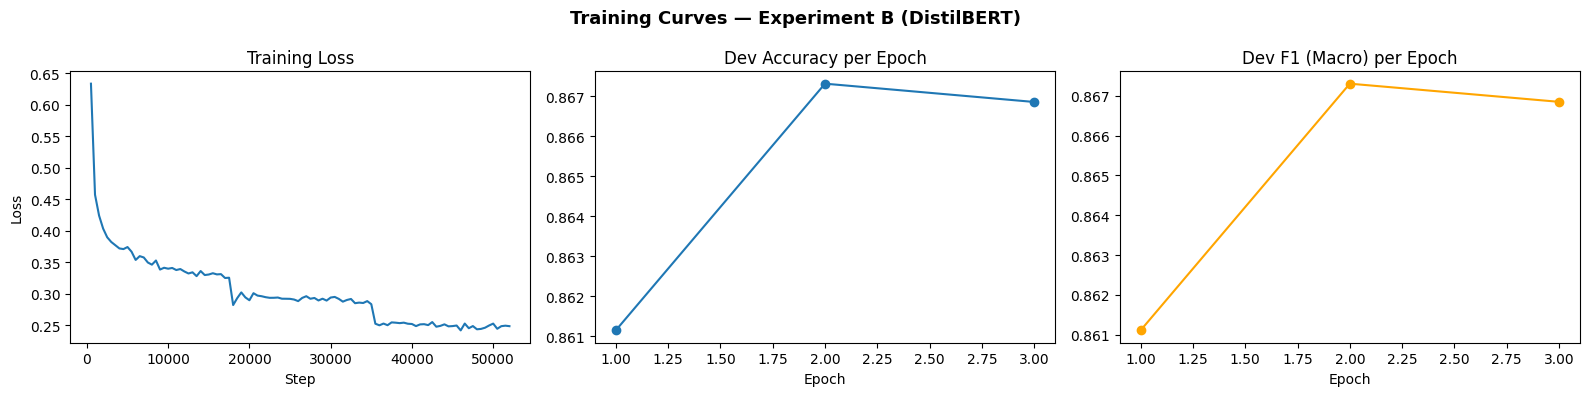

In [15]:
log_history = pd.DataFrame(trainer.state.log_history)

train_logs = log_history[log_history['loss'].notna()][['step', 'loss']]
eval_logs  = log_history[log_history['eval_accuracy'].notna()][['epoch', 'eval_accuracy', 'eval_f1_macro', 'eval_loss']]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_logs['step'], train_logs['loss'])
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')

axes[1].plot(eval_logs['epoch'], eval_logs['eval_accuracy'], marker='o')
axes[1].set_title('Dev Accuracy per Epoch'); axes[1].set_xlabel('Epoch')

axes[2].plot(eval_logs['epoch'], eval_logs['eval_f1_macro'], marker='o', color='orange')
axes[2].set_title('Dev F1 (Macro) per Epoch'); axes[2].set_xlabel('Epoch')

plt.suptitle('Training Curves — Experiment B (DistilBERT)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Final Evaluation on Test Set

Run once after training is complete.

Test Accuracy: 0.8677

              precision    recall  f1-score   support

    negative       0.86      0.87      0.87    159695
    positive       0.87      0.86      0.87    159729

    accuracy                           0.87    319424
   macro avg       0.87      0.87      0.87    319424
weighted avg       0.87      0.87      0.87    319424



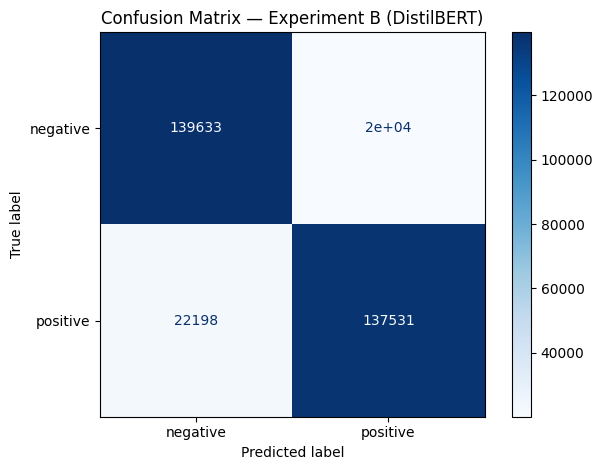

In [9]:
test_output = trainer.predict(test_ds)
y_test_pred = np.argmax(test_output.predictions, axis=1)
y_test_true = test_output.label_ids

print(f'Test Accuracy: {accuracy_score(y_test_true, y_test_pred):.4f}\n')
print(classification_report(y_test_true, y_test_pred, target_names=['negative', 'positive']))

cm = confusion_matrix(y_test_true, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['negative', 'positive']).plot(cmap='Blues')
plt.title('Confusion Matrix — Experiment B (DistilBERT)')
plt.tight_layout()
plt.show()

## 10. Save Model

Saves the fine-tuned model and tokenizer locally so Experiment C can load it without retraining.

In [10]:
SAVE_PATH = './distilbert_sentiment140_final'
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f'Model saved to {SAVE_PATH}')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.69it/s]


Model saved to ./distilbert_sentiment140_final


## 11. Predict on Custom Tweets

In [11]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model=model,
    tokenizer=tokenizer,
    device=0 if device == 'cuda' else -1,
    truncation=True,
    max_length=MAX_LENGTH
)

custom_tweets = [
    "just got the best coffee of my life absolutely love this place!",
    "my flight got cancelled again. third time this month. done with this airline",
    "can't believe how good this new album is, been on repeat all day",
    "so tired of this weather, everything is grey and miserable",
    "heading to the gym, feeling motivated today"
]

results = classifier(custom_tweets)
for tweet, result in zip(custom_tweets, results):
    print(f'[{result["label"]:8s}  {result["score"]:.3f}]  {tweet}')

[positive  0.998]  just got the best coffee of my life absolutely love this place!
[negative  0.838]  my flight got cancelled again. third time this month. done with this airline
[positive  0.955]  can't believe how good this new album is, been on repeat all day
[negative  0.997]  so tired of this weather, everything is grey and miserable
[positive  0.995]  heading to the gym, feeling motivated today


## 12. Summary

In [22]:
dev_output   = trainer.predict(dev_ds)
dev_preds    = np.argmax(dev_output.predictions, axis=1)
dev_accuracy = accuracy_score(dev_output.label_ids, dev_preds)
dev_f1       = f1_score(dev_output.label_ids, dev_preds, average='macro')

summary = {
    'Experiment':           'B — Transformer (DistilBERT)',
    'Model':                'distilbert-base-uncased',
    'Training samples':     len(X_train),
    'Test samples':         len(X_test),
    'Dev accuracy':         round(dev_accuracy, 4),
    'Test accuracy':        round(accuracy_score(y_test_true, y_test_pred), 4),
    'Test F1 (macro)':      round(f1_score(y_test_true, y_test_pred, average='macro'), 4),
    'Test F1 (negative)':   round(f1_score(y_test_true, y_test_pred, pos_label=0, average='binary'), 4),
    'Test F1 (positive)':   round(f1_score(y_test_true, y_test_pred, pos_label=1, average='binary'), 4),
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
print(summary_df.to_string(index=False))
summary_df.to_csv('experiment_b_results.csv', index=False)
print('\nSaved to experiment_b_results.csv')

            Metric                        Value
        Experiment B — Transformer (DistilBERT)
             Model      distilbert-base-uncased
  Training samples                      1117983
      Test samples                       319424
      Dev accuracy                       0.8673
     Test accuracy                       0.8677
   Test F1 (macro)                       0.8677
Test F1 (negative)                       0.8686
Test F1 (positive)                       0.8668

Saved to experiment_b_results.csv
